# TensorBoard Seed-Aggregated Training Curves

This notebook loads TensorBoard event logs from three random seeds, extracts scalar training metrics, aligns the curves by training step, and plots the across-seed mean ± standard deviation.

It produces side-by-side plots for:

1. Mean reward
2. A second scalar metric specified by `EXTRA_METRIC_TAG`

Update the configuration cell below with your three TensorBoard event-file paths or log directories.

## Notes

- Each path can be either a TensorBoard event file, such as `events.out.tfevents...`, or a directory containing one or more event files.
- If a directory contains multiple event files, the notebook loads scalar events from all event files in that directory.
- Curves are aligned on a common step grid before computing mean and standard deviation.
- If your three logs do not have exactly the same recorded steps, interpolation is used by default.

In [1]:
from pathlib import Path
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
except ImportError as e:
    raise ImportError(
        "This notebook requires tensorboard. Install it with: pip install tensorboard"
    ) from e

In [2]:
# =============================================================================
# Configuration
# =============================================================================

# Provide three TensorBoard log paths. Each entry can be either:
#   - a directory containing events.out.tfevents* files, or
#   - a direct path to one events.out.tfevents* file.
SEED_LOG_PATHS = [
    Path("../../logs/pact_corl/go1_pact_rough/May17_21-01-03_pact_100hz_spec_smartcurr_lower_jointrand_hightau"),
    Path("../../logs/pact_corl/go1_pact_rough/Jun01_09-32-32_pact_100hz_spec_smartcurr_weakest_jointrand_hightau"),
    Path("../../logs/pact_corl/go1_pact_rough/Jun01_09-45-03_pact_100hz_spec_smartcurr_lower_jointrand_hightau_03"),
]

SEED_LABELS = ["seed_0", "seed_1", "seed_2"]

# TensorBoard scalar tag for mean reward. Run the tag-inspection cell below
# if your logs use a different tag.
MEAN_REWARD_TAG = "Train/mean_reward"

# Second metric to plot. Change this to any scalar tag present in your logs.
EXTRA_METRIC_TAG = "Loss/pinn_loss"

MEAN_REWARD_LABEL = "Mean Reward"
EXTRA_METRIC_LABEL = "PINN Loss"

# Alignment options:
#   "intersection" -> only steps common to all seeds
#   "union"        -> union of all steps, interpolating missing values within each seed's range
#   "linspace"     -> uniform grid over the overlapping step range
ALIGNMENT_MODE = "union"
NUM_LINSPACE_POINTS = 500

# Optional centered rolling mean smoothing. Use 1 or None to disable.
SMOOTH_WINDOW = 1

FIGURE_SIZE = (10.0, 3.2)
SHADE_ALPHA = 0.22
LINEWIDTH = 2.2
SAVE_FIGURES = True
OUTPUT_DIR = Path("tensorboard_training_curve_results")
OUTPUT_BASENAME = "pact_seed_training_curves"

In [3]:
# =============================================================================
# TensorBoard loading utilities
# =============================================================================

def find_event_files(path):
    path = Path(path).expanduser()
    if path.is_file():
        return [path]
    if not path.exists():
        raise FileNotFoundError(f"Path does not exist: {path}")

    patterns = [
        str(path / "events.out.tfevents*"),
        str(path / "**" / "events.out.tfevents*"),
    ]
    files = []
    for pattern in patterns:
        files.extend(glob.glob(pattern, recursive=True))

    files = sorted(set(Path(f) for f in files))
    if not files:
        raise FileNotFoundError(f"No TensorBoard event files found under: {path}")
    return files


def load_scalar_events_from_file(event_file, tag=None):
    event_file = Path(event_file)
    acc = EventAccumulator(str(event_file), size_guidance={"scalars": 0})
    acc.Reload()
    scalar_tags = acc.Tags().get("scalars", [])

    if tag is None:
        rows = []
        for t in scalar_tags:
            for ev in acc.Scalars(t):
                rows.append({
                    "tag": t,
                    "step": int(ev.step),
                    "value": float(ev.value),
                    "wall_time": float(ev.wall_time),
                    "event_file": str(event_file),
                })
        return pd.DataFrame(rows)

    if tag not in scalar_tags:
        return pd.DataFrame(columns=["tag", "step", "value", "wall_time", "event_file"])

    rows = []
    for ev in acc.Scalars(tag):
        rows.append({
            "tag": tag,
            "step": int(ev.step),
            "value": float(ev.value),
            "wall_time": float(ev.wall_time),
            "event_file": str(event_file),
        })
    return pd.DataFrame(rows)


def load_scalar_tag_from_log_path(log_path, tag, seed_label):
    event_files = find_event_files(log_path)
    chunks = []
    for event_file in event_files:
        df = load_scalar_events_from_file(event_file, tag=tag)
        if len(df):
            chunks.append(df)

    if not chunks:
        warnings.warn(f"Tag {tag!r} not found in path: {log_path}")
        return pd.DataFrame(columns=["seed", "tag", "step", "value", "wall_time", "event_file"])

    out = pd.concat(chunks, ignore_index=True)
    out["seed"] = seed_label

    # Resumed runs can create repeated steps across event files. Keep the last
    # event by wall time for each seed/tag/step.
    out = (
        out.sort_values(["seed", "tag", "step", "wall_time"])
           .drop_duplicates(subset=["seed", "tag", "step"], keep="last")
           .sort_values(["seed", "tag", "step"], ignore_index=True)
    )
    return out


def load_scalar_tag_across_seeds(log_paths, seed_labels, tag):
    chunks = []
    for path, label in zip(log_paths, seed_labels):
        print(f"Loading tag {tag!r} from {label}: {path}")
        chunks.append(load_scalar_tag_from_log_path(path, tag, label))
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()


def list_available_scalar_tags(log_paths):
    rows = []
    for seed_idx, path in enumerate(log_paths):
        label = SEED_LABELS[seed_idx] if seed_idx < len(SEED_LABELS) else f"seed_{seed_idx}"
        event_files = find_event_files(path)
        tag_counts = {}
        for event_file in event_files:
            acc = EventAccumulator(str(event_file), size_guidance={"scalars": 0})
            acc.Reload()
            for tag in acc.Tags().get("scalars", []):
                try:
                    n = len(acc.Scalars(tag))
                except Exception:
                    n = np.nan
                tag_counts[tag] = tag_counts.get(tag, 0) + n
        for tag, n in sorted(tag_counts.items()):
            rows.append({"seed": label, "tag": tag, "num_events": n, "path": str(path)})
    return pd.DataFrame(rows)

## Inspect available scalar tags

Run this cell after setting `SEED_LOG_PATHS` if you are unsure what TensorBoard tag names were used for reward or the extra metric.

In [4]:
# Uncomment after setting SEED_LOG_PATHS above.
# tag_table = list_available_scalar_tags(SEED_LOG_PATHS)
# tag_table.sort_values(["tag", "seed"]).head(100)

In [5]:
# =============================================================================
# Alignment and aggregation utilities
# =============================================================================

def smooth_series(values, window):
    if window is None or window <= 1:
        return np.asarray(values, dtype=float)
    return (
        pd.Series(values, dtype=float)
        .rolling(window=int(window), center=True, min_periods=1)
        .mean()
        .to_numpy(dtype=float)
    )


def seed_curve_to_series(df):
    tmp = df[["step", "value"]].dropna().copy()
    tmp = tmp.sort_values("step")
    tmp = tmp.drop_duplicates("step", keep="last")
    return pd.Series(tmp["value"].to_numpy(dtype=float), index=tmp["step"].to_numpy(dtype=int))


def align_seed_curves(metric_df, mode="union", num_points=500, smooth_window=1):
    if len(metric_df) == 0:
        return pd.DataFrame(), pd.DataFrame()

    seed_series = {}
    for seed, g in metric_df.groupby("seed"):
        s = seed_curve_to_series(g)
        if len(s):
            seed_series[seed] = s

    if not seed_series:
        return pd.DataFrame(), pd.DataFrame()

    if mode == "intersection":
        common_steps = None
        for s in seed_series.values():
            steps = set(s.index.tolist())
            common_steps = steps if common_steps is None else common_steps & steps
        step_grid = np.asarray(sorted(common_steps), dtype=int)

    elif mode == "union":
        all_steps = sorted(set().union(*[set(s.index.tolist()) for s in seed_series.values()]))
        step_grid = np.asarray(all_steps, dtype=int)

    elif mode == "linspace":
        min_step = max(int(s.index.min()) for s in seed_series.values())
        max_step = min(int(s.index.max()) for s in seed_series.values())
        if max_step < min_step:
            raise ValueError("Seed curves do not overlap in step range; cannot use linspace alignment.")
        step_grid = np.linspace(min_step, max_step, int(num_points))

    else:
        raise ValueError(f"Unknown alignment mode: {mode}. Use 'intersection', 'union', or 'linspace'.")

    aligned = pd.DataFrame({"step": step_grid})

    for seed, s in seed_series.items():
        x = s.index.to_numpy(dtype=float)
        y = s.to_numpy(dtype=float)

        if mode == "intersection":
            vals = pd.Series(y, index=x).reindex(step_grid).to_numpy(dtype=float)
        else:
            vals = np.interp(step_grid.astype(float), x, y)
            vals[(step_grid < x.min()) | (step_grid > x.max())] = np.nan

        aligned[seed] = smooth_series(vals, smooth_window)

    seed_cols = [c for c in aligned.columns if c != "step"]
    values = aligned[seed_cols].to_numpy(dtype=float)

    summary = pd.DataFrame({
        "step": aligned["step"].to_numpy(),
        "mean": np.nanmean(values, axis=1),
        "std": np.nanstd(values, axis=1, ddof=1),
        "n": np.sum(np.isfinite(values), axis=1),
    })

    return aligned, summary


def load_align_and_summarize(tag, log_paths=SEED_LOG_PATHS, seed_labels=SEED_LABELS):
    raw = load_scalar_tag_across_seeds(log_paths, seed_labels, tag)
    aligned, summary = align_seed_curves(
        raw,
        mode=ALIGNMENT_MODE,
        num_points=NUM_LINSPACE_POINTS,
        smooth_window=SMOOTH_WINDOW,
    )
    return raw, aligned, summary

In [6]:
# =============================================================================
# Load and summarize the requested metrics
# =============================================================================

reward_raw, reward_aligned, reward_summary = load_align_and_summarize(MEAN_REWARD_TAG)
extra_raw, extra_aligned, extra_summary = load_align_and_summarize(EXTRA_METRIC_TAG)

print("Reward raw rows:", len(reward_raw))
print("Extra metric raw rows:", len(extra_raw))

reward_summary.head(), extra_summary.head()

Loading tag 'Train/mean_reward' from seed_0: ../../logs/pact_corl/go1_pact_rough/May17_21-01-03_pact_100hz_spec_smartcurr_lower_jointrand_hightau
Loading tag 'Train/mean_reward' from seed_1: ../../logs/pact_corl/go1_pact_rough/Jun01_09-32-32_pact_100hz_spec_smartcurr_weakest_jointrand_hightau
Loading tag 'Train/mean_reward' from seed_2: ../../logs/pact_corl/go1_pact_rough/Jun01_09-45-03_pact_100hz_spec_smartcurr_lower_jointrand_hightau_03
Loading tag 'Loss/pinn_loss' from seed_0: ../../logs/pact_corl/go1_pact_rough/May17_21-01-03_pact_100hz_spec_smartcurr_lower_jointrand_hightau
Loading tag 'Loss/pinn_loss' from seed_1: ../../logs/pact_corl/go1_pact_rough/Jun01_09-32-32_pact_100hz_spec_smartcurr_weakest_jointrand_hightau
Loading tag 'Loss/pinn_loss' from seed_2: ../../logs/pact_corl/go1_pact_rough/Jun01_09-45-03_pact_100hz_spec_smartcurr_lower_jointrand_hightau_03
Reward raw rows: 24000
Extra metric raw rows: 24000


(   step      mean       std  n
 0     0  0.003336  0.001089  3
 1     1  0.006269  0.000801  3
 2     2  0.008851  0.000717  3
 3     3  0.013285  0.002423  3
 4     4  0.022390  0.001637  3,
    step      mean       std  n
 0     0  0.000000  0.000000  3
 1     1  0.399346  0.001416  3
 2     2  0.412373  0.001981  3
 3     3  0.424683  0.001060  3
 4     4  0.437762  0.002860  3)

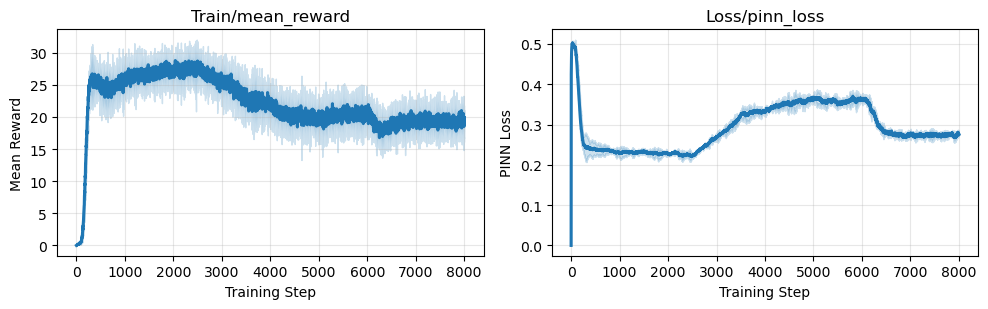

In [12]:
# =============================================================================
# Plotting
# =============================================================================

def plot_mean_std_curve(ax, summary, ylabel, title=None, color=None):
    if len(summary) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_ylabel(ylabel)
        if title is not None:
            ax.set_title(title)
        return ax

    x = summary["step"].to_numpy(dtype=float)
    mean = summary["mean"].to_numpy(dtype=float)
    std = summary["std"].fillna(0.0).to_numpy(dtype=float)

    if color is None:
        line = ax.plot(x, mean, linewidth=LINEWIDTH)[0]
        color = line.get_color()
    else:
        ax.plot(x, mean, linewidth=LINEWIDTH, color=color)

    ax.fill_between(x, mean - 2.0*std, mean + 2.0*std, alpha=SHADE_ALPHA, color=color)
    ax.set_xlabel("Training Step")
    ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)
    ax.grid(True, axis="both", alpha=0.3)
    return ax


def plot_training_curves(
    reward_summary,
    extra_summary,
    reward_label=MEAN_REWARD_LABEL,
    extra_label=EXTRA_METRIC_LABEL,
    reward_tag=MEAN_REWARD_TAG,
    extra_tag=EXTRA_METRIC_TAG,
):
    fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

    plot_mean_std_curve(axes[0], reward_summary, ylabel=reward_label, title=reward_tag)
    plot_mean_std_curve(axes[1], extra_summary, ylabel=extra_label, title=extra_tag)

    fig.tight_layout()
    return fig, axes


fig, axes = plot_training_curves(reward_summary, extra_summary)

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / f"{OUTPUT_BASENAME}.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(OUTPUT_DIR / f"{OUTPUT_BASENAME}.pdf", bbox_inches="tight", pad_inches=0.02)

plt.show()

## Save compact CSV outputs

These tables can be used to recreate the plots without re-reading the TensorBoard event files.

In [8]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

reward_raw.to_csv(OUTPUT_DIR / "mean_reward_raw_scalars.csv", index=False)
reward_aligned.to_csv(OUTPUT_DIR / "mean_reward_aligned_by_seed.csv", index=False)
reward_summary.to_csv(OUTPUT_DIR / "mean_reward_mean_std.csv", index=False)

extra_raw.to_csv(OUTPUT_DIR / "extra_metric_raw_scalars.csv", index=False)
extra_aligned.to_csv(OUTPUT_DIR / "extra_metric_aligned_by_seed.csv", index=False)
extra_summary.to_csv(OUTPUT_DIR / "extra_metric_mean_std.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR.resolve())

Saved outputs to: /home/oyoungquist/Research/Genesis_Development/HCR_Genesis_PACT_Development/legged_gym/scripts/tensorboard_training_curve_results


## Optional: plot individual seed curves

This can help diagnose whether one seed is an outlier or whether the TensorBoard tags were logged with different step ranges.

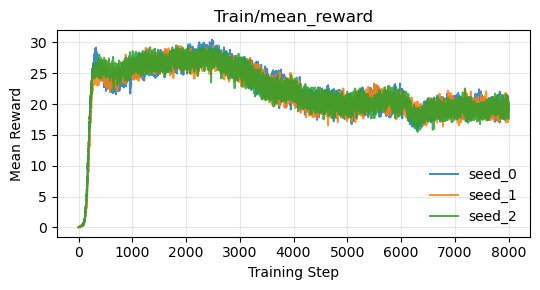

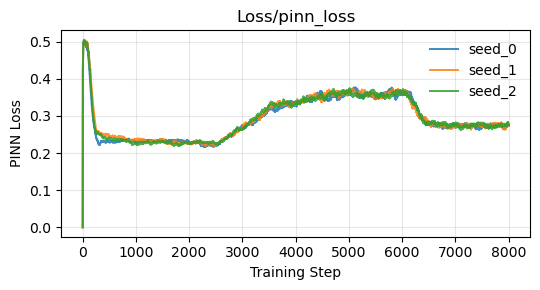

In [11]:
def plot_individual_seed_curves(raw_df, tag, ylabel):
    fig, ax = plt.subplots(figsize=(5.5, 3.0))
    for seed, g in raw_df.groupby("seed"):
        g = g.sort_values("step")
        ax.plot(g["step"], g["value"], linewidth=1.4, alpha=0.85, label=seed)
    ax.set_xlabel("Training Step")
    ax.set_ylabel(ylabel)
    ax.set_title(tag)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig, ax

# Example usage:
fig, ax = plot_individual_seed_curves(reward_raw, MEAN_REWARD_TAG, MEAN_REWARD_LABEL)
fig, ax = plot_individual_seed_curves(extra_raw, EXTRA_METRIC_TAG, EXTRA_METRIC_LABEL)